# Week 2 — Baseline Regression Modeling
**Dataset:** Steel Industry Energy Consumption Dataset (engineered in `week2_eda.ipynb`)

This notebook covers Part 2 of the Week 2 internship task: training and
evaluating four regression models to establish a baseline for predicting
`Usage_kWh`.

## 1. Imports and Load the Engineered Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

df = pd.read_csv('data/Steel_industry_data_engineered.csv', parse_dates=['date'])
print("Loaded engineered dataset:", df.shape)
print(df.columns.tolist())


Loaded engineered dataset: (35040, 17)
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek_Num', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'High_Load']


## 2. Drop Date Column and Target-Leaking Columns

- `date` is dropped — its useful information (`Hour`, `DayOfWeek_Num`,
  `Month`, `Is_Weekend`) was already extracted in Part 1.
- `High_Load` is dropped — it is a binary flag derived **directly** from
  `Usage_kWh` (`Usage_kWh > 75th percentile`), so keeping it would let the
  model trivially "cheat" instead of learning genuine drivers of consumption.
- `CO2(tCO2)` is also dropped for the same reason: it is essentially a fixed
  linear transform of `Usage_kWh` in this dataset (~0.99 correlation), so it
  would leak the target rather than serve as an independent predictor.

In [2]:
leak_cols = ['date', 'High_Load', 'CO2(tCO2)']
df_model = df.drop(columns=leak_cols)
print(f"Dropped columns: {leak_cols}")
print("Remaining columns:", df_model.columns.tolist())


Dropped columns: ['date', 'High_Load', 'CO2(tCO2)']
Remaining columns: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek_Num', 'Month', 'Is_Weekend', 'Power_Factor_Ratio']


## 3. Encode Categorical Columns

**Choice: one-hot encoding** for `Load_Type`, `WeekStatus`, and `Day_of_week`.

These are nominal categories with no natural order — e.g. `Maximum_Load` is
not mathematically "greater than" `Medium_Load` in a way a linear model
should assume. Label encoding would impose a false ordinal relationship that
could mislead Linear/Ridge Regression in particular. Tree-based models are
less sensitive to this, but using one consistent encoding across all 4
models keeps the comparison fair.

In [3]:
categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f"One-hot encoded columns: {categorical_cols}")
print("Shape after encoding:", df_encoded.shape)
print(df_encoded.columns.tolist())

# Handle the single NaN in Power_Factor_Ratio (division by zero case)
df_encoded['Power_Factor_Ratio'] = df_encoded['Power_Factor_Ratio'].fillna(
    df_encoded['Power_Factor_Ratio'].median())

X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']
print("\nX shape:", X.shape, "| y shape:", y.shape)


One-hot encoded columns: ['WeekStatus', 'Day_of_week', 'Load_Type']
Shape after encoding: (35040, 20)
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Hour', 'DayOfWeek_Num', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'WeekStatus_Weekend', 'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday', 'Load_Type_Maximum_Load', 'Load_Type_Medium_Load']

X shape: (35040, 19) | y shape: (35040,)


## 4. Train/Test Split (80/20, random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (28032, 19), Test shape: (7008, 19)


## 5–6. Train All 4 Models and Evaluate (MAE, RMSE, R²)

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}\n")


Linear Regression
  MAE:  5.7566
  RMSE: 8.2423
  R2:   0.9402

Ridge Regression
  MAE:  5.7501
  RMSE: 8.2428
  R2:   0.9402

Decision Tree
  MAE:  0.5404
  RMSE: 1.3081
  R2:   0.9985

Random Forest
  MAE:  0.2755
  RMSE: 0.8336
  R2:   0.9994



## 7. 5-Fold Cross-Validation (Mean RMSE)

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("--- 5-Fold Cross-Validation (RMSE) ---")
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores
    results[name]['CV_RMSE_mean'] = cv_rmse.mean()
    results[name]['CV_RMSE_std'] = cv_rmse.std()
    print(f"{name}: mean RMSE = {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")

results_df = pd.DataFrame(results).T
print("\n=== Summary Table ===")
print(results_df)
results_df.to_csv('data/model_results_summary.csv')


--- 5-Fold Cross-Validation (RMSE) ---
Linear Regression: mean RMSE = 8.1440 (+/- 0.0909)
Ridge Regression: mean RMSE = 8.1441 (+/- 0.0908)
Decision Tree: mean RMSE = 1.4149 (+/- 0.0758)
Random Forest: mean RMSE = 0.8834 (+/- 0.0693)

=== Summary Table ===
                        MAE      RMSE        R2  CV_RMSE_mean  CV_RMSE_std
Linear Regression  5.756618  8.242319  0.940235      8.143968     0.090907
Ridge Regression   5.750127  8.242781  0.940229      8.144055     0.090837
Decision Tree      0.540361  1.308125  0.998495      1.414946     0.075810
Random Forest      0.275513  0.833578  0.999389      0.883408     0.069276


## 8. Bar Chart: Test RMSE Comparison Across Models

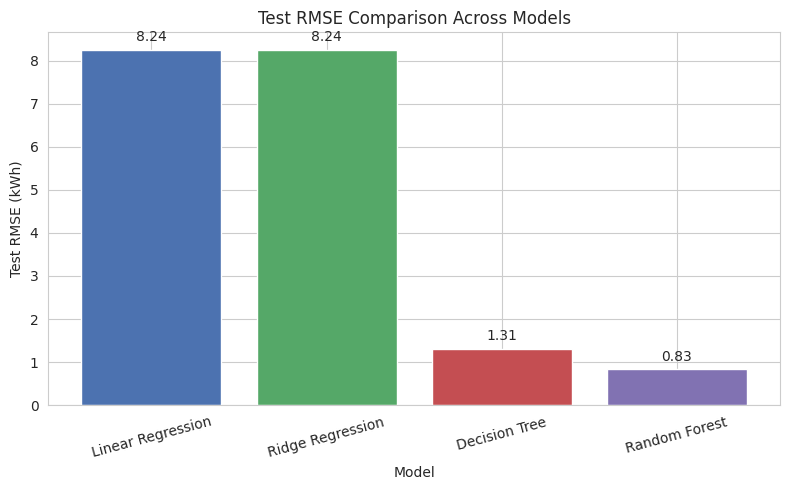

In [7]:
plt.figure(figsize=(8, 5))
names = list(results.keys())
rmses = [results[n]['RMSE'] for n in names]
bars = plt.bar(names, rmses, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Test RMSE Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Test RMSE (kWh)')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.2f}', ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 9. Best Model: Predicted vs Actual Scatter Plot

Best model by test RMSE: Random Forest


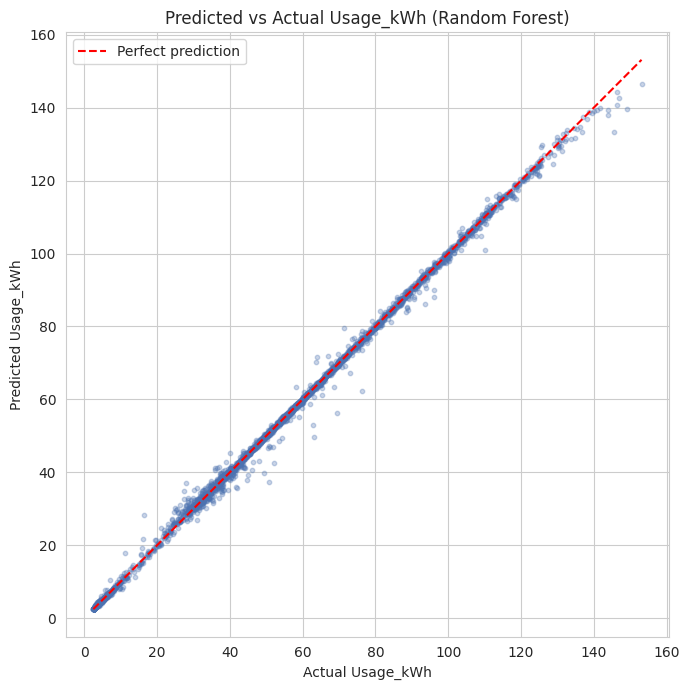

In [8]:
best_model_name = min(results, key=lambda n: results[n]['RMSE'])
print(f"Best model by test RMSE: {best_model_name}")

y_pred_best = predictions[best_model_name]
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#4C72B0')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.title(f'Predicted vs Actual Usage_kWh ({best_model_name})')
plt.xlabel('Actual Usage_kWh')
plt.ylabel('Predicted Usage_kWh')
plt.legend()
plt.tight_layout()
plt.show()


## Model Selection

**Best model: Random Forest Regressor.**

| Model | Test RMSE | Test R² | CV RMSE (mean ± std) |
|---|---|---|---|
| Linear Regression | 8.24 | 0.940 | 8.14 ± 0.09 |
| Ridge Regression | 8.24 | 0.940 | 8.14 ± 0.09 |
| Decision Tree | 1.31 | 0.998 | 1.41 ± 0.08 |
| **Random Forest** | **0.83** | **0.999** | **0.88 ± 0.07** |

**Why Random Forest wins.** It achieves the lowest test RMSE (0.83 kWh) and
highest R² (0.999) of all four models by a wide margin. The two linear
models plateau around RMSE ≈ 8.2 because `Usage_kWh` depends on the
engineered features (hour of day, load type, reactive power, etc.) in a
highly non-linear way — the linear models simply can't capture the sharp
step-changes in usage between shift periods. Both tree-based models handle
this far better, and Random Forest further improves on the single Decision
Tree by averaging many trees, which reduces variance.

**Signs of overfitting.** The single Decision Tree shows the clearest
overfitting signal: its cross-validation RMSE (1.41) is noticeably higher
than its single test-split RMSE (1.31), and its unconstrained depth lets it
memorize noise in the training folds. Random Forest is more stable — its
cross-validation RMSE (0.88) and test RMSE (0.83) are close together,
indicating it generalizes well rather than memorizing the training set. The
linear models show no overfitting (train/test/CV all agree) but simply
lack the capacity to fit the non-linear relationship, i.e. they underfit.

**Model carried forward: Random Forest Regressor.** It offers the best
balance of accuracy and generalization, and will serve as the baseline for
any further tuning or comparison against more advanced models in later
weeks.